In [1]:
# Convert waveform .root file to h5 sample file

import uproot as uproot
import numpy as np
import pandas as pd
from tqdm import tqdm

import h5py
import os
from os import path
import matplotlib.pyplot as plt

In [2]:
WIRE_EDGES = {0: [0, 1984, 3968, 5638,], # tpc0
              1: [5638, 5638+1984, 5638+3968, 5638+5638]} # tpc1

# Single interesting events

In [3]:
this_raw_file = "/exp/sbnd/app/users/munjung/v10_06_00_02-dnnsp/jobs/waveform.root"
wvfm = uproot.open(this_raw_file+":wvfm/raw_wvfm")
klist = list(wvfm.keys())
print(klist)
this_key = "run_18515_sub_1_evt_29363_raw"

['run_18515_sub_1_evt_20233_raw;1', 'run_18515_sub_1_evt_20343_raw;1', 'run_18515_sub_1_evt_21047_raw;1', 'run_18515_sub_1_evt_21245_raw;1', 'run_18515_sub_1_evt_21531_raw;1', 'run_18515_sub_1_evt_22191_raw;1', 'run_18515_sub_1_evt_22257_raw;1', 'run_18515_sub_1_evt_22345_raw;1', 'run_18515_sub_1_evt_22719_raw;1', 'run_18515_sub_1_evt_23005_raw;1', 'run_18515_sub_1_evt_23489_raw;1', 'run_18515_sub_1_evt_23599_raw;1', 'run_18515_sub_1_evt_24193_raw;1', 'run_18515_sub_1_evt_24435_raw;1', 'run_18515_sub_1_evt_24963_raw;1', 'run_18515_sub_1_evt_26041_raw;1', 'run_18515_sub_1_evt_26481_raw;1', 'run_18515_sub_1_evt_26569_raw;1', 'run_18515_sub_1_evt_26767_raw;1', 'run_18515_sub_1_evt_27031_raw;1', 'run_18515_sub_1_evt_27251_raw;1', 'run_18515_sub_1_evt_27295_raw;1', 'run_18515_sub_1_evt_27471_raw;1', 'run_18515_sub_1_evt_27691_raw;1', 'run_18515_sub_1_evt_27977_raw;1', 'run_18515_sub_1_evt_28219_raw;1', 'run_18515_sub_1_evt_29363_raw;1', 'run_18515_sub_1_evt_29495_raw;1', 'run_18515_sub_1_ev

In [4]:
save_path = "/scratch/7DayLifetime/munjung/anomaly-detection-raw-h5"
subdir = "run_18515_sub_1_evt_29363"
if not os.path.exists(path.join(save_path, subdir)):
    os.makedirs(path.join(save_path, subdir))
print("output directory: ", os.path.join(save_path, subdir))

tpc = 1
save_name_tag_raw = "g4-raw-{}".format(tpc)
hf_raw = h5py.File(path.join(save_path, subdir, "{}.h5".format(save_name_tag_raw)), "w") 

output directory:  /scratch/7DayLifetime/munjung/anomaly-detection-raw-h5/run_18515_sub_1_evt_29363


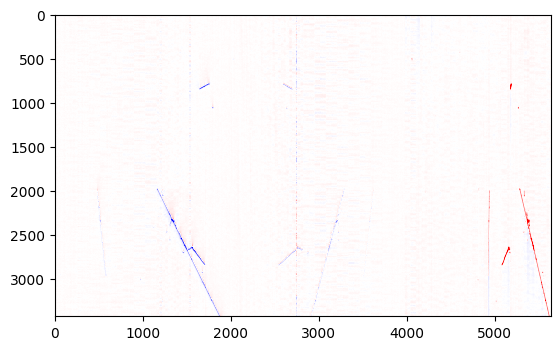

In [5]:
arr = wvfm[this_key].values()
this_arr = arr[WIRE_EDGES[tpc][0]:WIRE_EDGES[tpc][-1]]
plt.imshow(this_arr.T, vmin=-50, vmax=50, cmap="bwr")
plt.show();

In [6]:
wnevts = 0
tag_raw = "raw"

g1 = hf_raw.create_group('/%d'%(wnevts))
g1.create_dataset(tag_raw, data=this_arr)

hf_raw.close()
wvfm.close()
print("done")

done


# Single File

In [ ]:
n_events_per_file = 10
tag_raw = "raw"
tpc = 0

this_dir = "/pnfs/sbnd/scratch/users/munjung/v10_06_00/raw-SBND_DATA_InTimeCosmics_offbeamlight/waveforms/27333755_0"
save_path = this_dir

this_raw_file = path.join(this_dir, "waveform.root")
wvfm = uproot.open(this_raw_file+":wvfm/raw_wvfm")
klist = list(wvfm.keys())

nfile = 0
wnevts = 0
save_name_tag_raw = "g4-raw-{}_{}".format(tpc, nfile)
hf_raw = h5py.File(path.join(save_path, "{}.h5".format(save_name_tag_raw)), "w") 

for evtno in tqdm(range(len(klist))):
    arr = wvfm[klist[evtno]].values()
    this_arr = arr[WIRE_EDGES[tpc][0]:WIRE_EDGES[tpc][-1]]
    g1 = hf_raw.create_group('/%d'%(wnevts))
    g1.create_dataset(tag_raw, data=this_arr)
    wnevts = wnevts + 1

    if wnevts == n_events_per_file:
        print("moving to next file")
        hf_raw.close()
        nfile  = nfile + 1
        save_name_tag_raw = "g4-raw-{}_{}".format(tpc, nfile)
        hf_raw = h5py.File(path.join(save_path, "{}.h5".format(save_name_tag_raw)), "w") 
        wnevts = 0

wvfm.close()
print("done")

done


# Loop over job outputs

In [2]:
# !ls /scratch/7DayLifetime/munjung/anomaly-detection-raw/83487027_49
# !rm -rf /scratch/7DayLifetime/munjung/anomaly-detection-raw/83487027_59
# !rm /scratch/7DayLifetime/munjung/anomaly-detection-raw/83487027_*/*-0.h5

In [ ]:
with open("/exp/sbnd/app/users/munjung/misc/filelists/decoded/wvfms_xrootd.list", "r") as f:
    raw_lines = [line.strip() for line in f if line.strip()]
print("number of raw files", len(raw_lines))

save_path = "/scratch/7DayLifetime/munjung/anomaly-detection-raw-h5"
sudir_tag = "83487027"
print("output directory: ", save_path)

number of raw files 1863
output directory:  /scratch/7DayLifetime/munjung/anomaly-detection-raw-h5


In [ ]:
tag_raw = "raw"
# plane = 0
tpc = 0

In [5]:
n_events_per_file = 10
print("saving h5 files with raw frames of tpc {} with {} events per file".format(tpc, n_events_per_file))

nfile = 0
wnevts = 0

subdir = "{}_{}".format(sudir_tag, 0)
if not os.path.exists(path.join(save_path, subdir)):
    os.makedirs(path.join(save_path, subdir))

save_name_tag_raw = "g4-raw-{}_{}".format(tpc, nfile)
hf_raw = h5py.File(path.join(save_path, subdir, "{}.h5".format(save_name_tag_raw)), "w") 

for i in tqdm(range(0, 300)):
    print(i)
    !. ~/get_token.sh

    nfile = 0

    subdir = "{}_{}".format(sudir_tag, i)
    if not os.path.exists(path.join(save_path, subdir)):
        print("making directory", path.join(save_path, subdir))
        os.makedirs(path.join(save_path, subdir))

    this_raw_file = raw_lines[i]
    wvfm = uproot.open(this_raw_file+":wvfm/raw_wvfm")
    klist = list(wvfm.keys())

    for evtno in range(len(klist)):
        arr = wvfm[klist[evtno]].values()
        this_arr = arr[WIRE_EDGES[tpc][0]:WIRE_EDGES[tpc][-1]]
        g1 = hf_raw.create_group('/%d'%(wnevts))
        g1.create_dataset(tag_raw, data=this_arr)
        wnevts = wnevts + 1

        if (i == len(raw_lines)-1) and (evtno == len(klist)-1):
            print("last event")
            hf_raw.close()
            if wnevts > 0:
                # delete the file with the last event
                os.remove(path.join(save_path, subdir, "{}.h5".format(save_name_tag_raw)))
                print("deleted the file with the last event, since it's incomplete")

        if wnevts == n_events_per_file:
            # print("moving to next file")
            hf_raw.close()
            nfile  = nfile + 1
            save_name_tag_raw = "g4-raw-{}_{}".format(tpc, nfile)
            hf_raw = h5py.File(path.join(save_path, subdir, "{}.h5".format(save_name_tag_raw)), "w") 
            wnevts = 0

    wvfm.close()

print("done")

saving h5 files with raw frames of tpc 0 with 10 events per file


  0%|          | 0/300 [00:00<?, ?it/s]

0
Attempting to get token from https://htvaultprod.fnal.gov:8200 ... succeeded
Storing bearer token in /tmp/bt_u57582


  0%|          | 1/300 [00:52<4:20:43, 52.32s/it]

1
Attempting to get token from https://htvaultprod.fnal.gov:8200 ... succeeded
Storing bearer token in /tmp/bt_u57582
making directory /scratch/7DayLifetime/munjung/anomaly-detection-raw-h5/83487027_1


...

39
Attempting to get token from https://htvaultprod.fnal.gov:8200 ... succeeded
Storing bearer token in /tmp/bt_u57582
making directory /scratch/7DayLifetime/munjung/anomaly-detection-raw-h5/83487027_39


 13%|█▎        | 40/300 [36:03<3:55:22, 54.32s/it]

40
Attempting to get token from https://htvaultprod.fnal.gov:8200 ... succeeded
Storing bearer token in /tmp/bt_u57582
making directory /scratch/7DayLifetime/munjung/anomaly-detection-raw-h5/83487027_40


: 

: 